# Sahel Rainfall Trends

Compare monthly precipitation (`avg_tprate`) between a historical period (1990–2000)
and a future period (2040–2050) under SSP3-7.0 for ICON and IFS-FESOM models.

Data is fetched from the Climate DT Generation 2 **monthly (clmn)** stream
via `PolytopeZarrStore`, using a bounding box over the Sahel region:
lat 10°S–25°N, lon 55°E–20°W.

Store config defines the full multi-year dataset instantly (no data downloaded).
Spatial subsetting and time slicing are applied via `.polytope.sel()` which
auto-batches requests — a single Polytope call fetches all years at once.

In [21]:
import sys, os
_here = os.getcwd()
if "../get-data" not in sys.path:
    sys.path.insert(0, "../get-data")

import logging, warnings
import earthkit.data
import earthkit.plots
import numpy as np
from polytope_zarr import PolytopeZarrStore

# Silence verbose polytope / earthkit output
for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [22]:
# ── Configuration ──────────────────────────────────────────────────
MODELS = ["ICON", "IFS-FESOM"]
BBOX = (-10, -20, 25, 55)  # (south, west, north, east)

# Historical and future periods
PERIODS = {
    "hist": ("hist", range(1990, 2001)),
    "fut":  ("SSP3-7.0", range(2040, 2051)),
}

In [23]:
# ── Build lazy stores (metadata only — no data fetched yet) ────────
hist_store = PolytopeZarrStore.from_climate_dt(
    models=MODELS,
    experiment="hist",
    levtype="sfc",
    years=range(1990, 2001),
)

fut_store = PolytopeZarrStore.from_climate_dt(
    models=MODELS,
    experiment="SSP3-7.0",
    levtype="sfc",
    years=range(2040, 2051),
)

In [24]:
# ── Open as xarray Datasets (still lazy) ───────────────────────────
ds_hist = hist_store.open()
ds_fut  = fut_store.open()

print("Historical store:", ds_hist)
print("\nFuture store:", ds_fut)

Historical store: <xarray.Dataset> Size: 7GB
Dimensions:       (model: 2, time: 132, cell: 196608)
Coordinates:
  * model         (model) object 16B 'ICON' 'IFS-FESOM'
  * time          (time) datetime64[ns] 1kB 1990-01-01 1990-02-01 ... 2000-12-01
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    avg_10u       (model, time, cell) float32 208MB ...
    avg_10v       (model, time, cell) float32 208MB ...
    avg_10ws      (model, time, cell) float32 208MB ...
    avg_2d        (model, time, cell) float32 208MB ...
    avg_2t        (model, time, cell) float32 208MB ...
    avg_ie        (model, time, cell) float32 208MB ...
    ...            ...
    avg_tnlwrf    (model, time, cell) float32 208MB ...
    avg_tnlwrfcs  (model, time, cell) float32 208MB ...
    avg_tnswrf    (model, time, cell) float32 208MB ...
    avg_tnswrfcs  (model, time, cell) float32 208MB ...
    avg_tprate    (model, time, cell) float32 208MB ...
    avg_t

In [26]:
# ── Fetch spatially‑subsetted climatologies with batching ──────────
# .polytope.sel() auto‑sets batch_years from the time slice, so each
# call = a single Polytope request per model × period

diff_data = {}  # model -> xr.DataArray

for model in MODELS:
    print(f"Fetching {model} ...")

    # Historical: 1990-01 to 2000-12
    hist_field = ds_hist["avg_tprate"].polytope.sel(
        model=model, time=slice("1990-01", "2000-12"), bbox=BBOX
    )
    clim_hist = hist_field.mean("time")

    # Future: 2040-01 to 2050-12
    fut_field = ds_fut["avg_tprate"].polytope.sel(
        model=model, time=slice("2040-01", "2050-12"), bbox=BBOX
    )
    clim_fut = fut_field.mean("time")

    # Difference: future − historical, convert kg m⁻² s⁻¹ → mm/day
    diff = (clim_fut - clim_hist) * 86400
    diff_data[model] = diff

Fetching ICON ...
  🌍 boundingbox request for avg_tprate (1990/1991/1992/1993/1994/1995/1996/1997/1998/1999/2000-1/2/3/4/5/6/7/8/9/10/11/12)


8f819cb5-cf70-4fee-85bf-8ca0fe10749d.covjson:   0%|          | 0.00/86.0M [00:00<?, ?B/s]

  🌍 boundingbox request for avg_tprate (2040/2041/2042/2043/2044/2045/2046/2047/2048/2049/2050-1/2/3/4/5/6/7/8/9/10/11/12)


e27a7ac9-009f-4b89-b755-ade84b6bc5b3.covjson:   0%|          | 0.00/78.3M [00:00<?, ?B/s]

Fetching IFS-FESOM ...
  🌍 boundingbox request for avg_tprate (1990/1991/1992/1993/1994/1995/1996/1997/1998/1999/2000-1/2/3/4/5/6/7/8/9/10/11/12)


7b086000-4d8e-4cd5-a383-ab9bd29fd851.covjson:   0%|          | 0.00/82.0M [00:00<?, ?B/s]

  🌍 boundingbox request for avg_tprate (2040/2041/2042/2043/2044/2045/2046/2047/2048/2049/2050-1/2/3/4/5/6/7/8/9/10/11/12)


92d00862-be3b-45a4-bc41-97e115fba998.covjson:   0%|          | 0.00/74.2M [00:00<?, ?B/s]

In [34]:
style = earthkit.plots.styles.Style(
    colors="BrBG",
    levels=[-3,-2.5,-2,-1.5,-1,-.5,0,.5,1,1.5,2,2.5,3],
    extend="both",
    units="mm/day",
)

/home/dorian.spat/miniconda3/envs/destine/lib/python3.11/site-packages/earthkit/plots/sources/__init__.py:273: UserWarning: Unit conversion failed for z: kg m**-2 s**-1 -> mm/day. Error: Cannot convert from 'kilogram / meter ** 2 / second' ([mass] / [length] ** 2 / [time]) to 'millimeter / day' ([length] / [time]). Returning original values.
  warnings.warn(


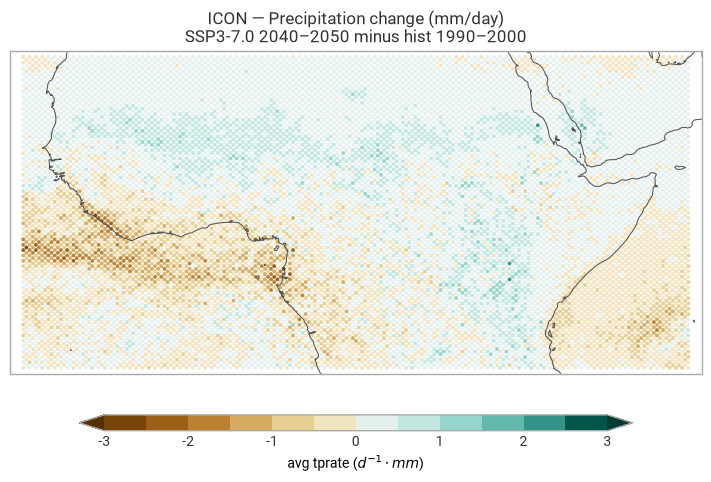

In [41]:
# ── Plot: ICON ────────────────────────────────────────────────────
chart = earthkit.plots.Map()
chart.point_cloud(diff_data["ICON"], style=style)
chart.coastlines()
chart.title("ICON — Precipitation change (mm/day)\nSSP3-7.0 2040–2050 minus hist 1990–2000")
chart.legend()
chart.show()
chart.save("plots/pr_change_icon.png")

/home/dorian.spat/miniconda3/envs/destine/lib/python3.11/site-packages/earthkit/plots/sources/__init__.py:273: UserWarning: Unit conversion failed for z: kg m**-2 s**-1 -> mm/day. Error: Cannot convert from 'kilogram / meter ** 2 / second' ([mass] / [length] ** 2 / [time]) to 'millimeter / day' ([length] / [time]). Returning original values.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

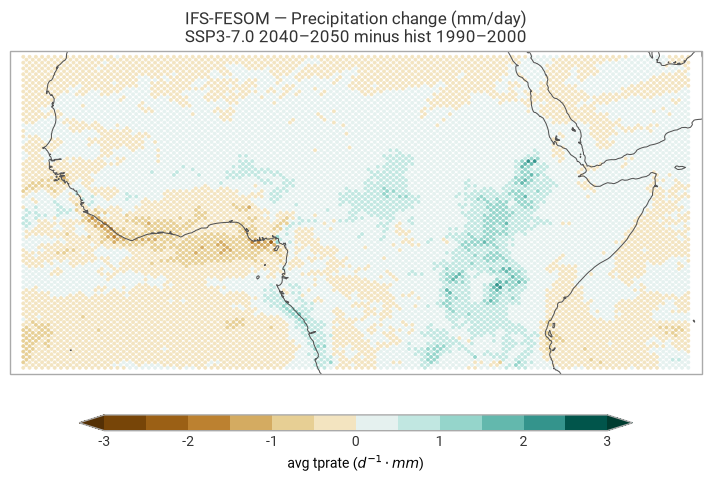

In [42]:
# ── Plot: IFS-FESOM ────────────────────────────────────────────────
chart = earthkit.plots.Map()
chart.point_cloud(diff_data["IFS-FESOM"], style=style)
chart.coastlines()
chart.title("IFS-FESOM — Precipitation change (mm/day)\nSSP3-7.0 2040–2050 minus hist 1990–2000")
chart.legend()
chart.show()
chart.save("plots/pr_change_ifsfesom.png")

In [ ]:
# ── Clean up (optional) ────────────────────────────────────────────
hist_store.clear_cache()
fut_store.clear_cache()